In [56]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import classification_report

In [45]:
import pandas as pd

df = pd.read_csv(
    "Teen_Mental_Health_Dataset.csv",
    header=0,
    na_values=' ?'
    )

df.head()

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


In [46]:
df = df.drop_duplicates(df)
df =  df.drop(columns=["depression_label"])

In [47]:
import numpy as np
from sklearn.model_selection import train_test_split

X = df.drop('anxiety_level', axis = 1)
X = X.select_dtypes(include=[np.number])
y = df['anxiety_level']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=1,
    stratify=y
    )

print(X_train.shape)
print(X_test.shape)

(960, 8)
(240, 8)


In [59]:
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import root_mean_squared_error
from sklearn.model_selection import RandomizedSearchCV

param_distributions = {
    'n_estimators':range(1, 201),
    }

random_search = RandomizedSearchCV(
    estimator=bag_model,
    param_distributions=param_distributions,
    scoring='neg_root_mean_squared_error',
    n_iter=20,
    random_state=2
    )

random_search.fit(X_train, y_train)

print(f'Best validation score: {-random_search.best_score_:.3f} with parameters: {random_search.best_params_}')
print(f'Train score: {-random_search.score(X_train, y_train):.3f}')
print(f'Test score: {-random_search.score(X_test, y_test):.3f}')


Best validation score: 2.905 with parameters: {'n_estimators': 200}
Train score: 2.351
Test score: 2.902


In [60]:
mse = mean_squared_error(y_test, y_pred)

print(mse)

NameError: name 'mean_squared_error' is not defined

In [50]:
print(classification_report(
    y_test,
    grid_search.best_estimator_.predict(X_test)
    ))

              precision    recall  f1-score   support

           1       0.10      0.05      0.06        21
           2       0.13      0.18      0.15        22
           3       0.17      0.20      0.18        25
           4       0.17      0.19      0.18        26
           5       0.11      0.10      0.10        21
           6       0.12      0.15      0.14        26
           7       0.00      0.00      0.00        22
           8       0.09      0.08      0.08        26
           9       0.18      0.24      0.21        25
          10       0.22      0.15      0.18        26

    accuracy                           0.14       240
   macro avg       0.13      0.13      0.13       240
weighted avg       0.13      0.14      0.13       240



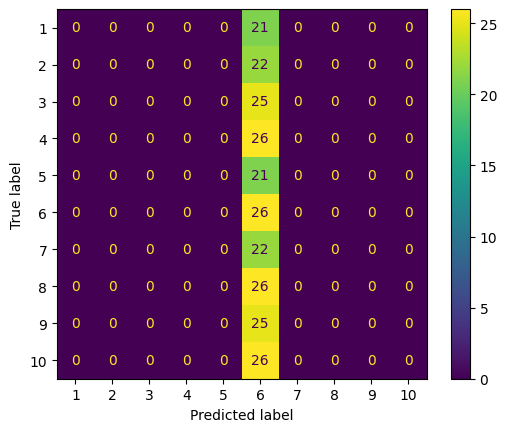

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test);

In [52]:
importances = pd.Series(model.feature_importances_, index=X_train.columns)
importances.sort_values(ascending=False)

age                         0.0
daily_social_media_hours    0.0
sleep_hours                 0.0
screen_time_before_sleep    0.0
academic_performance        0.0
physical_activity           0.0
stress_level                0.0
addiction_level             0.0
dtype: float64